# Resposta temporal d'un sistema massa-molla-amortidor

En aquest notebook es calcula la **resposta temporal** d'un sistema mecànic equivalent format per:

- massa equivalent
- amortiment
- rigidesa

El sistema es modela mitjançant una **funció de transferència de segon ordre** i es calcula la seva **resposta impulsional** utilitzant `scipy.signal`.

Resposta analítica:
        ⎛       -3.0⋅t                                -3.0⋅t           ⎞     
0.00024⋅⎝3.125⋅ℯ      ⋅sin(4.0⋅t) + 4.16666666666667⋅ℯ      ⋅cos(4.0⋅t)⎠⋅θ(t)

Expressió tancada:
⎛         -3.0⋅t                     -3.0⋅t           ⎞     
⎝0.00075⋅ℯ      ⋅sin(4.0⋅t) + 0.001⋅ℯ      ⋅cos(4.0⋅t)⎠⋅θ(t)

Valor inicial: 1/1000
Valor final: 0


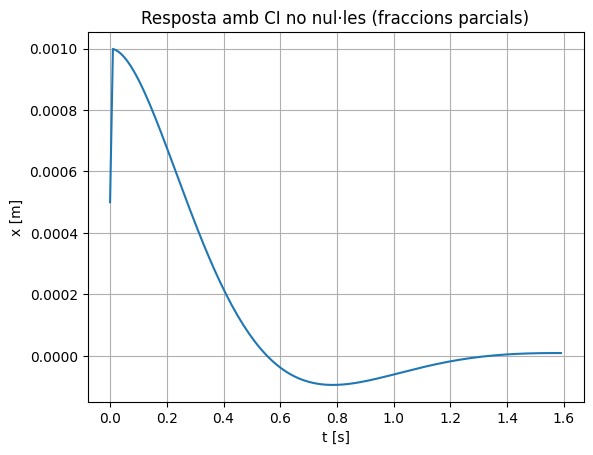

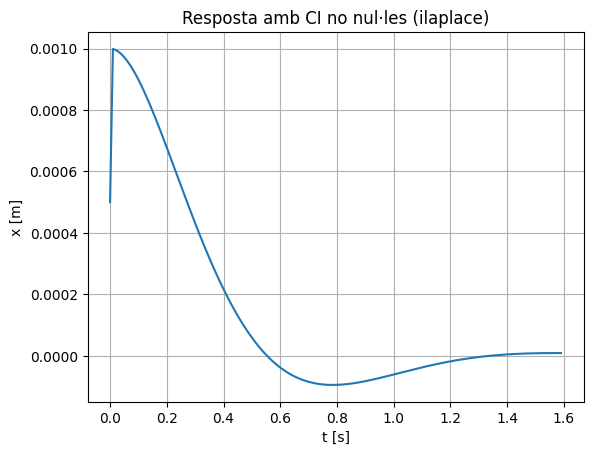

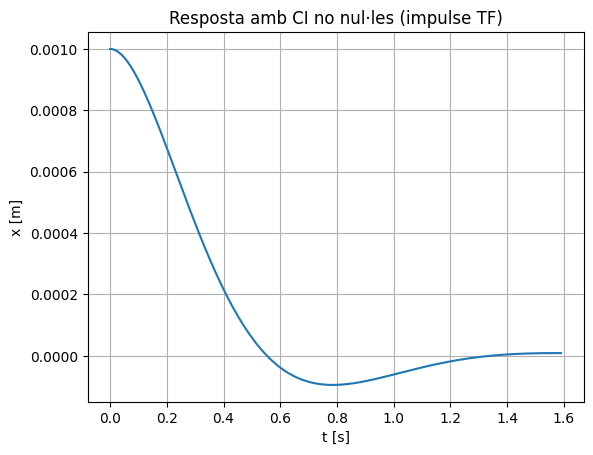

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from scipy import signal

# -------------------------
# Dades exercici
# -------------------------
m = 108
c = 78
k = 2925

m_eq = (m + 1/12*m)/9
c_eq = c
k_eq = k/9

x0 = 1e-3

t_ = np.arange(0,1.6,0.01)


# ==========================================================
# MÈTODE 1 — Fraccions parcials
# ==========================================================
s,t = sp.symbols('s t', real=True)

F = (x0*m_eq*s + c_eq*x0)/(m_eq*s**2 + c_eq*s + k_eq)

# fraccions parcials
F_part = sp.apart(F,s)

f = sp.inverse_laplace_transform(F_part,s,t)

print("Resposta analítica:")
sp.pretty_print(f)

# avaluació numèrica
f_num = sp.lambdify(t,f,'numpy')
ff_ = f_num(t_)

plt.figure()
plt.plot(t_,ff_)
plt.xlabel('t [s]')
plt.ylabel('x [m]')
plt.title('Resposta amb CI no nul·les (fraccions parcials)')
plt.grid(True)


# ==========================================================
# MÈTODE 2 — ilaplace directe
# ==========================================================
f2 = sp.inverse_laplace_transform(F,s,t)

print("\nExpressió tancada:")
sp.pretty_print(f2)

# teoremes valor inicial i final
initial_value = sp.limit(s*F, s, sp.oo)
final_value = sp.limit(s*F, s, 0)

print("\nValor inicial:",initial_value)
print("Valor final:",final_value)

f2_num = sp.lambdify(t,f2,'numpy')
f_ = f2_num(t_)

plt.figure()
plt.plot(t_,f_)
plt.xlabel('t [s]')
plt.ylabel('x [m]')
plt.title('Resposta amb CI no nul·les (ilaplace)')
plt.grid(True)


# ==========================================================
# MÈTODE 3 — Equivalent a impulse de TF
# ==========================================================

num = [x0*m_eq, x0*c_eq]
den = [m_eq, c_eq, k_eq]

system = signal.TransferFunction(num,den)

t_imp, y_imp = signal.impulse(system, T=t_)

plt.figure()
plt.plot(t_imp,y_imp)
plt.xlabel('t [s]')
plt.ylabel('x [m]')
plt.title('Resposta amb CI no nul·les (impulse TF)')
plt.grid(True)

plt.show()